In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("..")


from optimizers.gd import gd
from optimizers.sgd import  sgd 
from optimizers.momentum import momentum
from optimizers.nag import nag
from optimizers.adam import adam





# ======================
# 2. Quadratic Problem Definition
# ======================
A = np.array([[3., 1.], [1., 2.]])
b = np.array([2., 5.])
x_star = np.linalg.inv(A) @ b

def quadratic_loss(w, A, b):
    return (w.T @ A @ w) - 2 * (b.T @ w)

def quadratic_gradient(w, A, b):
    return 2 * (A @ w) - 2 * b

# ======================
# 3. Fixed Test Runner
# ======================
def run_quadratic_test(optimizer_func, 
                       start_position= np.array([3,4]), 
                       lr=0.001, 
                       steps=100, 
                       title="Optimizer", 
                       atol=1e-6, 
                       **kwargs):
    """
    Runs and visualizes any optimizer.
    """
    # Call optimizer with CORRECT argument order (positional for loss/grad)
    final_w, losses, path = optimizer_func(
        start_position, 
        A, 
        b,
        quadratic_loss,       # loss_func (positional)
        quadratic_gradient,   # gradient_func (positional)
        lr=lr, 
        steps=steps,
        **kwargs
    )
   
    # Correctness check
    error = np.linalg.norm(final_w - x_star)
    assert error < atol, (
        f"{title} did not converge!\n Got: {final_w}\n Expected: {x_star}\n Error: {error}"
    )
    print(f"✓ {title} converged to {final_w} (target: {x_star})")

    # Monotonic loss check for vanilla GD
    losses = np.array(losses)
    if "gradient descent" in title.lower() or title.lower() == "gd":
        if not np.all(np.diff(losses) <= 1e-8):
            print(" ⚠ Warning: loss was not monotonically decreasing")

    # ======================
    # Plotting
    # ======================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Loss Curve
    ax1.plot(losses, marker='o', color='blue', markersize=3)
    ax1.set_title(f"Loss Curve (Learning Rate: {lr})")
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("f(x)")
    ax1.grid(True)

    # Contour Map + Path
    x1_range = np.linspace(-5, 5, 100)
    x2_range = np.linspace(-2, 5, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    
    pts = np.stack([X1.ravel(), X2.ravel()], axis=1)
    Z = np.array([quadratic_loss(p, A, b) for p in pts]).reshape(X1.shape)

    ax2.contour(X1, X2, Z, levels=25, cmap='viridis')
    
    path = np.array(path)
    ax2.plot(path[:, 0], path[:, 1], color='red', marker='x', 
             markersize=4, label=f'{title} Path')
    ax2.plot(x_star[0], x_star[1], color='gold', marker='*', 
             markersize=15, label='Exact Minimum (x*)')
    
    ax2.set_title(f"{title} Path down the Quadratic Bowl")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()



✓ Gradient Descent converged to [-0.2  2.6] (target: [-0.2  2.6])


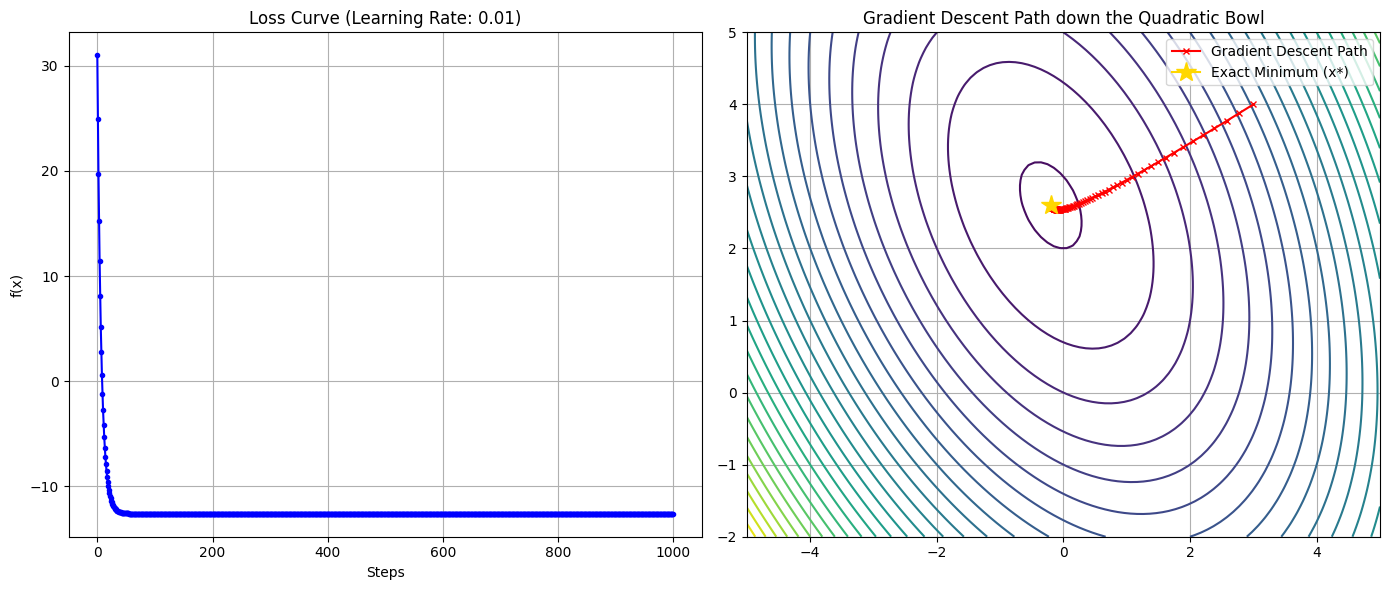

In [2]:
# ======================
# 4. Run GD
# ======================
run_quadratic_test(
    optimizer_func=gd,   # now correctly imported
    lr=0.01,
    steps=1000,
    title="Gradient Descent"
)

✓ Gradient Descent with Momentum converged to [-0.19999961  2.60000026] (target: [-0.2  2.6])
 ⚠ Warning: loss was not monotonically decreasing


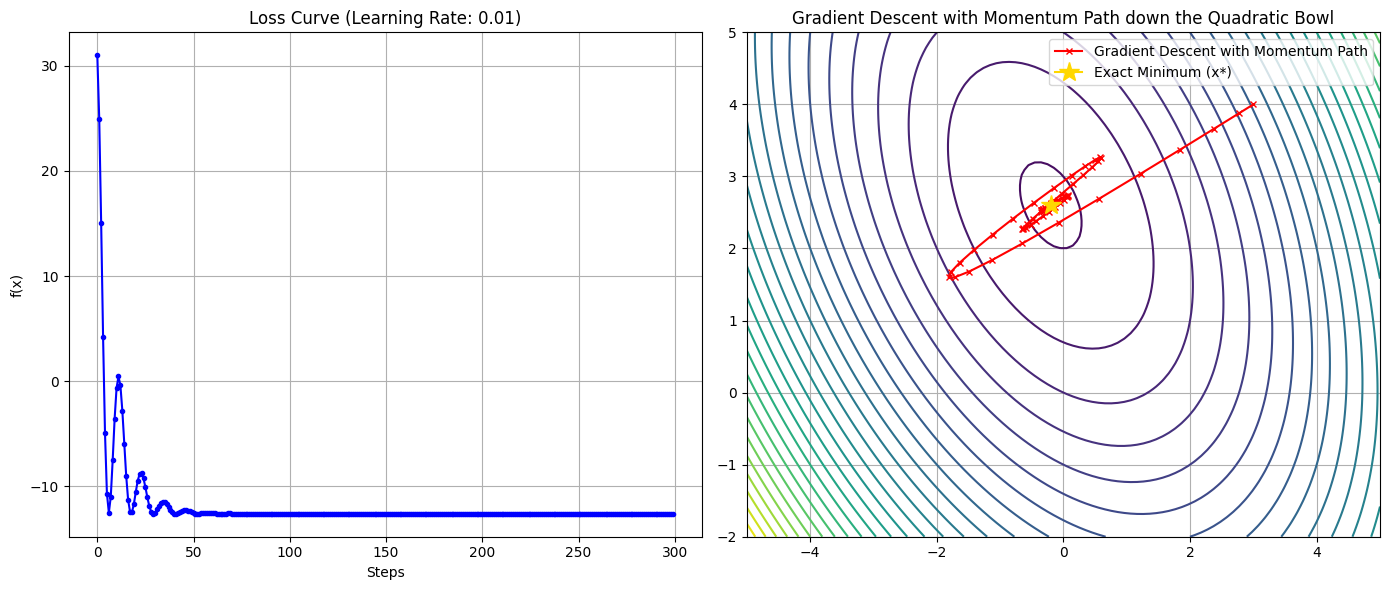

In [3]:
# Run GD with momentum 
run_quadratic_test(optimizer_func=momentum,
                   lr=0.01,
                   steps=300,
                   title="Gradient Descent with Momentum",
                   beta=0.9
                   )

✓ Nesterov Accelerated Gradient converged to [-0.2  2.6] (target: [-0.2  2.6])


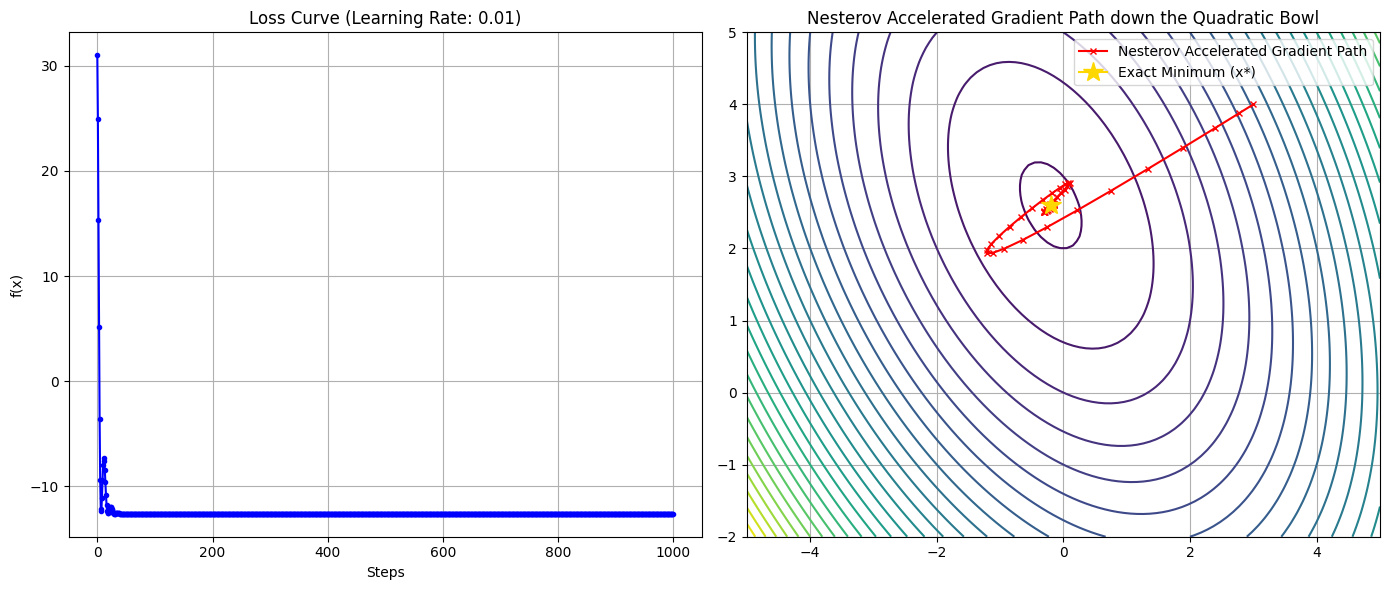

In [4]:
# Run NAG
run_quadratic_test(
    optimizer_func=nag,
    lr=0.01,
    steps=1000,
    title="Nesterov Accelerated Gradient",
    beta=0.9
)

✓ Adam Optimizer converged to [-0.2  2.6] (target: [-0.2  2.6])


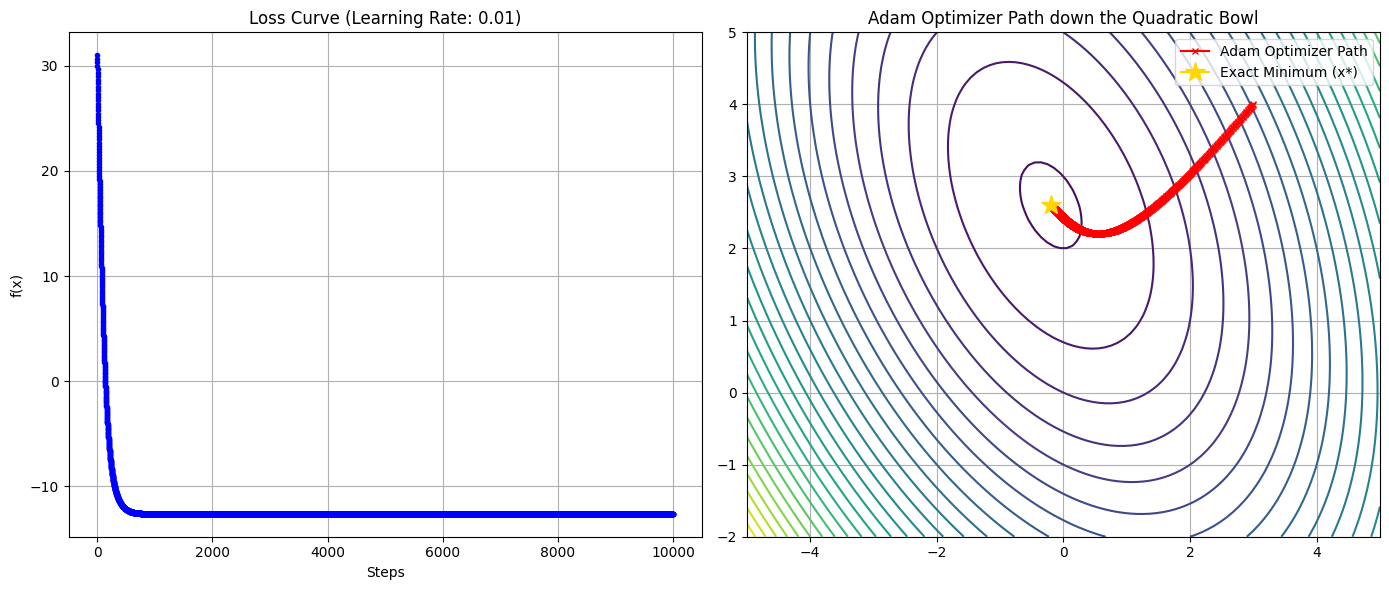

In [7]:
# Run Adam
run_quadratic_test(
    optimizer_func=adam,
    lr=0.01,
    steps=10000,
    title="Adam Optimizer"
)

✓ Stochastic Gradient Descent (SGD) converged to [-0.2  2.6] (target: [-0.2  2.6])
 ⚠ Warning: loss was not monotonically decreasing


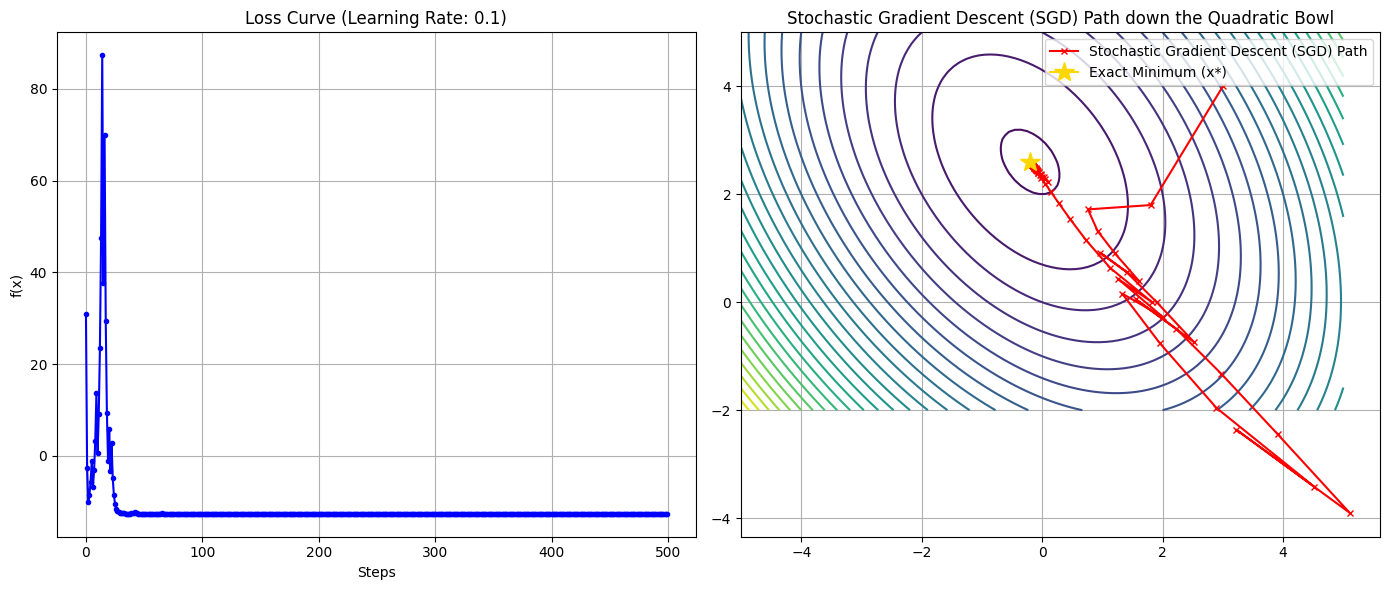

In [6]:


# Run SGD
run_quadratic_test(
    optimizer_func=sgd,
    lr=0.1,
    steps=500,
    title="Stochastic Gradient Descent (SGD)",
    batch_size=2,          # you can experiment with this later
    seed=42
)